<a href="https://colab.research.google.com/github/skylerbrough/MATH575/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project 1**

Research Questions (semi-tentative; to be expanded through data exploration):
1. Descriptive - What is the average minimum required experience to be eligible for a data science job?
2. Descriptive - Do in-person jobs pay worse than remote jobs?
3. Inference - How well can average salary be predicted for different jobs based on a variety of features?
4. Inference - CLassification: can we use salary, company type, and year posted to predict the type of job posted (i.e. remote_type)

----------------
1. Inference/Classify: What factors are associated with a job being Remote vs Onsite/Hybrid?
2. Inference (OLS): After controlling for experience level and job title, is there still a salary difference between Remote/Hybrid/Onsite roles?
3. Descriptive + inference: Which job titles or industries have the best entry-level pay (or highest salary ranges) and how consistent is that across countries?
4. Inference: Do startups pay differently than MNCs or research labs after adjusting for role + experience?
5. Descriptive/Inference: What predicts the width of the salary band?

In [ ]:
#This file is a python notebook for all data linked to this project.

#Original Research Question: What is the overall, lowest required experience to become eligible for a data science job on average? Combination of years of experience and level of expertise.

In [3]:
#mount the google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#load the CSV from the google drive

import pandas as pd

#load the CSV into dataframe
df = pd.read_csv("/content/drive/MyDrive/MATH575Project1/ai_jobs.csv")
df.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large


In [ ]:
#old github only instructions

# #loading data from kaggle
# import os
# from zipfile import ZipFile

# #make sure the data folder exists
# os.makedirs("data", exist_ok=True)

# #download the data if not already downloaded
# if not os.path.exists("data/global-ai-and-data-science-job-market-20202026.zip"):
#     !kaggle datasets download -d mann14/global-ai-and-data-science-job-market-20202026 -p data

# #unzip the data if not already unzipped
# zip_path = "data/global-ai-and-data-science-job-market-20202026.zip"
# if os.path.exists(zip_path):
#     with ZipFile(zip_path, "r") as zip_ref:
#         zip_ref.extractall("data")


In [ ]:
# #github only instructions

# #putting locally stored data into df
# import pandas as pd

# #load the CSV into dataframe
# df = pd.read_csv("data/ai_jobs.csv")
# df.head()


,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large


In [5]:
#check for missing data

print(df.isna().sum())
#no missing data!

print(df.duplicated().sum())
#no duplicated rows!

job_id                  0
job_title               0
company_type            0
industry                0
country                 0
city                    0
remote_type             0
experience_level        0
min_experience_years    0
salary_min_usd          0
salary_max_usd          0
employment_type         0
posted_year             0
company_size            0
dtype: int64
0


In [6]:
#check for outliers, impossible values, or improperly encoded values
for col in df.columns:
    print(f"\nValue counts for column: {col}")
    print(df[col].value_counts())

#job_title data is for six different jobs, with oddly similar counts in each
#company_type has three levels, also oddly similar counts in each
#industry has five levels, also oddly similar counts
#country has six levels, limited ability to generalize beyond these countries
#city data has 25 levels (24 cities + remote) and is all from large cities; limited ability to apply findings to Boise data science jobs
#remote_type has three levels and matches remote values from the city column
#experience_level has three levels
#employment_type shows that all jobs are full time
#posted_year has data from 7 years (2020-2026)
#company_size has three levels

#oddly similar classes across all categorical variables show some cherry picking of data which is not representative of the actual distribution of jobs in the job market.


Value counts for column: job_id
job_id
N14CJQT33BV9    1
00M0UWIL8URK    1
CEV7860N14W3    1
AD3XDGQ0NZP7    1
U3EZE48N7BKN    1
               ..
F0T0PVN9ER14    1
QJ7YHL1C32OC    1
CX1945NQ4FMY    1
ZMF8MDD4V30T    1
0IFD0TVBDIVU    1
Name: count, Length: 50000, dtype: int64

Value counts for column: job_title
job_title
MLOps Engineer               8439
AI Researcher                8415
Data Scientist               8410
Applied Scientist            8298
Data Analyst                 8260
Machine Learning Engineer    8178
Name: count, dtype: int64

Value counts for column: company_type
company_type
Research Lab    16910
MNC             16576
Startup         16514
Name: count, dtype: int64

Value counts for column: industry
industry
Tech          10083
Healthcare    10029
Retail         9979
Finance        9970
Education      9939
Name: count, dtype: int64

Value counts for column: country
country
UK           8452
India        8350
Germany      8345
Canada       8303
Australia    8276

In [7]:
#check for outliers or impossible values on salary columns
print(df[['salary_min_usd', 'salary_max_usd']].describe())

#no unreasonable min or max values
#median < mean shows a slight right skew which is common for salary data
#maxes at 180K is weird, there are definitely data scientists making 300K+; seems like a deliberate data collection choice

(df['salary_max_usd'] - df['salary_min_usd'] < 0).any() #all maxes are larger than mins

       salary_min_usd  salary_max_usd
count    50000.000000    50000.000000
mean    100871.434320   120858.350740
std      37043.446641    37531.386484
min      50000.000000    65000.000000
25%      61287.000000    83739.000000
50%      97505.000000   117604.000000
75%     143730.500000   161348.750000
max     154999.000000   180000.000000


np.False_

In [8]:
#new columns which might help later descriptive and inferential stats
df['salary_range'] = df['salary_max_usd'] - df['salary_min_usd']
df['salary_mid'] = (df['salary_max_usd'] + df['salary_min_usd'])/2

#I'll leave one-hot encoding for later steps as if I encode all categorical columns it will add a ton of columns to the dataset and make it hard to manage in the meantime

In [9]:
#part 2 - Pradeep - EDA

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

print(df.shape)
display(df.head())
df.info()

(50000, 16)


,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size,salary_range,salary_mid
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large,15350,64548.0
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium,30796,70201.0
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large,25826,162893.0
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium,32994,69980.0
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large,24321,115137.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job_id                50000 non-null  object 
 1   job_title             50000 non-null  object 
 2   company_type          50000 non-null  object 
 3   industry              50000 non-null  object 
 4   country               50000 non-null  object 
 5   city                  50000 non-null  object 
 6   remote_type           50000 non-null  object 
 7   experience_level      50000 non-null  object 
 8   min_experience_years  50000 non-null  int64  
 9   salary_min_usd        50000 non-null  int64  
 10  salary_max_usd        50000 non-null  int64  
 11  employment_type       50000 non-null  object 
 12  posted_year           50000 non-null  int64  
 13  company_size          50000 non-null  object 
 14  salary_range          50000 non-null  int64  
 15  salary_mid         

Data quality checks (missing values + duplicates + basic sanity)

In [10]:
df.isna().sum().sort_values(ascending=False)


,0
job_id,0
job_title,0
company_type,0
industry,0
country,0
city,0
remote_type,0
experience_level,0
min_experience_years,0
salary_min_usd,0


Inference: There are no missing values in any column

In [12]:
df["job_id"].nunique(), len(df)

(50000, 50000)

In [13]:
(df["salary_min_usd"] > df["salary_max_usd"]).sum()

np.int64(0)

Feature engineering for better EDA (mid salary + salary range)

In [14]:
df["salary_mid_usd"] = (df["salary_min_usd"] + df["salary_max_usd"]) / 2
df["salary_range_usd"] = df["salary_max_usd"] - df["salary_min_usd"]

df[["salary_min_usd","salary_max_usd","salary_mid_usd","salary_range_usd"]].describe()

,salary_min_usd,salary_max_usd,salary_mid_usd,salary_range_usd
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,100871.434320,120858.350740,110864.892530,19986.916420
std,37043.446641,37531.386484,37049.338755,8427.918624
min,50000.000000,65000.000000,57607.500000,56.000000
25%,61287.000000,83739.000000,70673.875000,13667.000000
50%,97505.000000,117604.000000,107565.250000,19986.000000
75%,143730.500000,161348.750000,154331.750000,26277.000000
max,154999.000000,180000.000000,167468.000000,39843.000000


Categorical distributions (what’s most common)

In [15]:
cat_cols = ["job_title","company_type","industry","country","city",
            "remote_type","experience_level","employment_type",
            "posted_year","company_size"]

for c in cat_cols:
    print("\n", c)
    print(df[c].value_counts().head(10))


 job_title
job_title
MLOps Engineer               8439
AI Researcher                8415
Data Scientist               8410
Applied Scientist            8298
Data Analyst                 8260
Machine Learning Engineer    8178
Name: count, dtype: int64

 company_type
company_type
Research Lab    16910
MNC             16576
Startup         16514
Name: count, dtype: int64

 industry
industry
Tech          10083
Healthcare    10029
Retail         9979
Finance        9970
Education      9939
Name: count, dtype: int64

 country
country
UK           8452
India        8350
Germany      8345
Canada       8303
Australia    8276
USA          8274
Name: count, dtype: int64

 city
city
Remote        16478
Brisbane       1909
London         1895
Manchester     1893
Vancouver      1869
Birmingham     1868
Melbourne      1864
Sydney         1852
Montreal       1844
Toronto        1814
Name: count, dtype: int64

 remote_type
remote_type
Hybrid    16984
Onsite    16538
Remote    16478
Name: count, dtype

Salary distribution + outliers

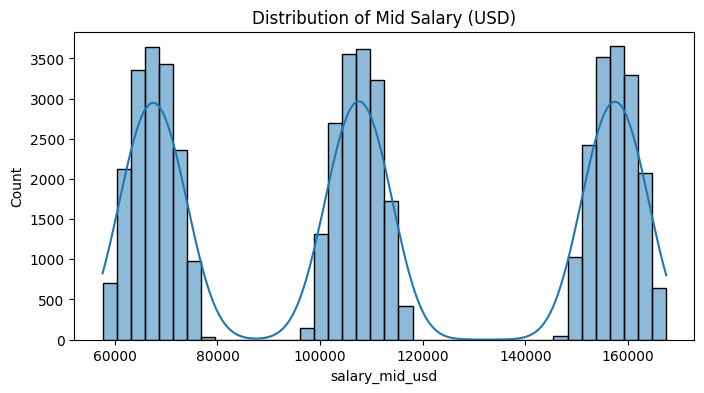

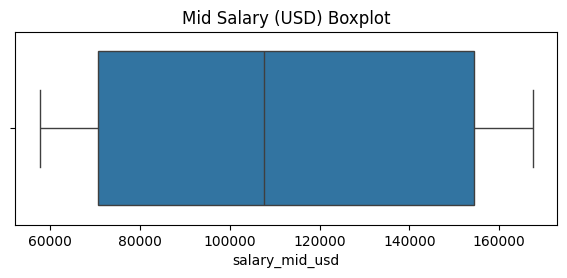

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df["salary_mid_usd"], kde=True, bins=40)
plt.title("Distribution of Mid Salary (USD)")
plt.show()

plt.figure(figsize=(7,2.5))
sns.boxplot(x=df["salary_mid_usd"])
plt.title("Mid Salary (USD) Boxplot")
plt.show()

In [17]:
df["salary_mid_usd"].quantile([0.01, 0.05, 0.5, 0.95, 0.99])

,salary_mid_usd
0.01,59961.905
0.05,62776.500
0.50,107565.250
0.95,162202.025
0.99,165033.535


Salary vs Experience

In [18]:
df.groupby("experience_level")["salary_mid_usd"].agg(["count","mean","median","min","max"]).sort_values("mean", ascending=False)

,count,mean,median,min,max
experience_level,,,,,
Senior,16677,157490.178359,157468.5,147556.0,167468.0
Mid,16695,107507.124049,107541.5,97572.0,117416.5
Entry,16628,67473.507698,67469.5,57607.5,77382.5


In [19]:
df.groupby("experience_level")["min_experience_years"].describe()

,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
Entry,16628.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Mid,16695.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0
Senior,16677.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0


Salary vs Job Title / Remote Type / Country / Company

In [20]:
df.groupby("job_title")["salary_mid_usd"].agg(["count","mean","median"]).sort_values("mean", ascending=False)

,count,mean,median
job_title,,,
Applied Scientist,8298,111382.242167,107826.50
Data Analyst,8260,111343.315133,107717.00
Machine Learning Engineer,8178,110816.692345,107528.25
Data Scientist,8410,110740.231570,107621.25
AI Researcher,8415,110574.632620,107483.00
MLOps Engineer,8439,110348.288541,107214.50


By Remote Type

In [21]:
df.groupby("remote_type")["salary_mid_usd"].agg(["count","mean","median"]).sort_values("mean", ascending=False)

,count,mean,median
remote_type,,,
Hybrid,16984,111169.122969,107677.00
Remote,16478,110910.661033,107564.75
Onsite,16538,110506.855091,107430.25


By Country

In [22]:
df.groupby("country")["salary_mid_usd"].agg(["count","mean","median"]).sort_values("mean", ascending=False)

,count,mean,median
country,,,
Australia,8276,111485.412337,107806.50
USA,8274,111057.537165,107686.50
UK,8452,111039.290582,107637.75
Germany,8345,110897.890294,107532.50
India,8350,110396.954910,107285.25
Canada,8303,110314.312839,107476.50


By Company type and Size

In [23]:
df.groupby("company_type")["salary_mid_usd"].agg(["count","mean","median"]).sort_values("mean", ascending=False)

df.groupby("company_size")["salary_mid_usd"].agg(["count","mean","median"]).sort_values("mean", ascending=False)

,count,mean,median
company_size,,,
Large,16654,110926.278492,107571.25
Small,16667,110903.200876,107576.00
Medium,16679,110765.317795,107544.00


Correlation analysis

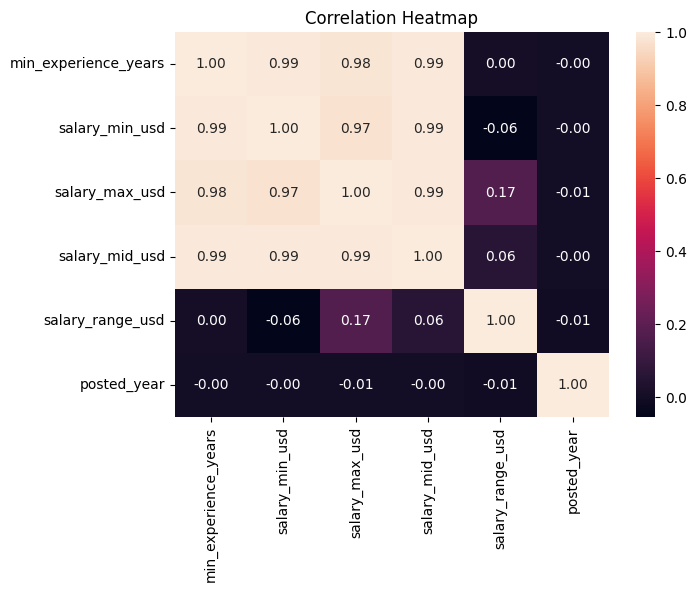

In [24]:
num_cols = ["min_experience_years","salary_min_usd","salary_max_usd","salary_mid_usd","salary_range_usd","posted_year"]
corr = df[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Trends over time (posted year vs salary)

In [25]:
df.groupby("posted_year")["salary_mid_usd"].agg(["count","mean","median"]).sort_index()

,count,mean,median
posted_year,,,
2020,7205,110757.182443,107539.00
2021,7128,111400.320356,107760.00
2022,7135,110873.484373,107623.00
2023,7035,111394.903554,107722.50
2024,7312,110348.491794,107378.50
2025,7043,110617.191183,107471.00
2026,7142,110681.480888,107460.75


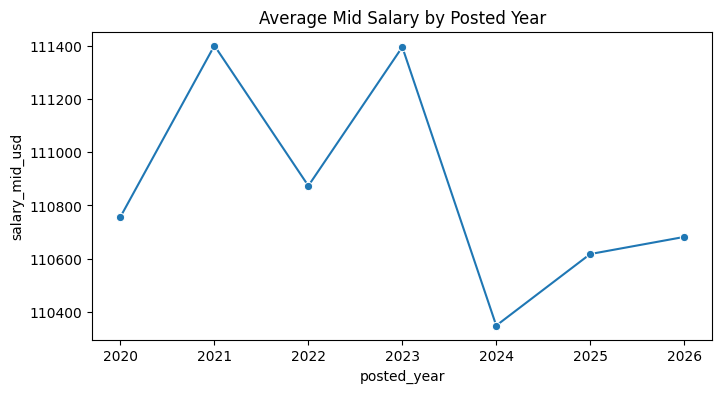

In [26]:
year_salary = df.groupby("posted_year")["salary_mid_usd"].mean().reset_index()

plt.figure(figsize=(8,4))
sns.lineplot(data=year_salary, x="posted_year", y="salary_mid_usd", marker="o")
plt.title("Average Mid Salary by Posted Year")
plt.show()

In [27]:
avg_exp_ds = df.loc[df["job_title"]=="Data Scientist", "min_experience_years"].mean()
avg_exp_ds

np.float64(2.324732461355529)

In [30]:
#part 3 - Jack - Inference

import pandas as pd
import numpy as np
import random
import seaborn as sns
import math
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import ISLP
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

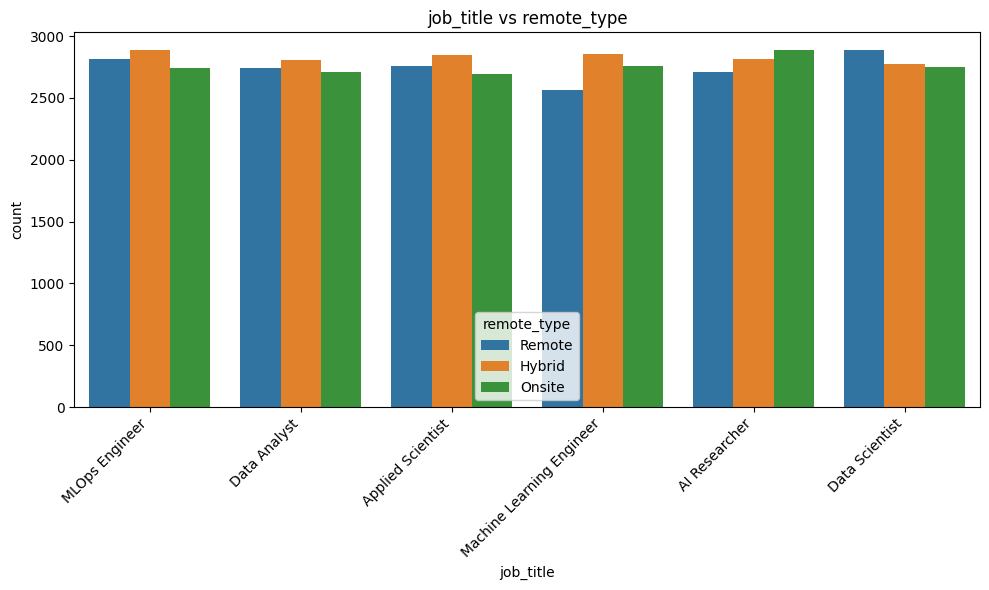

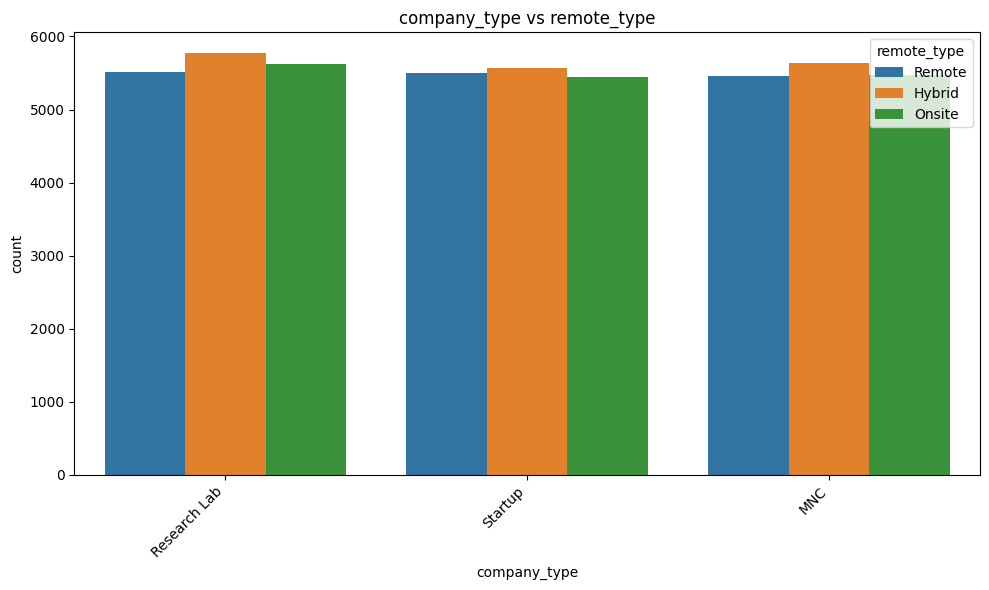

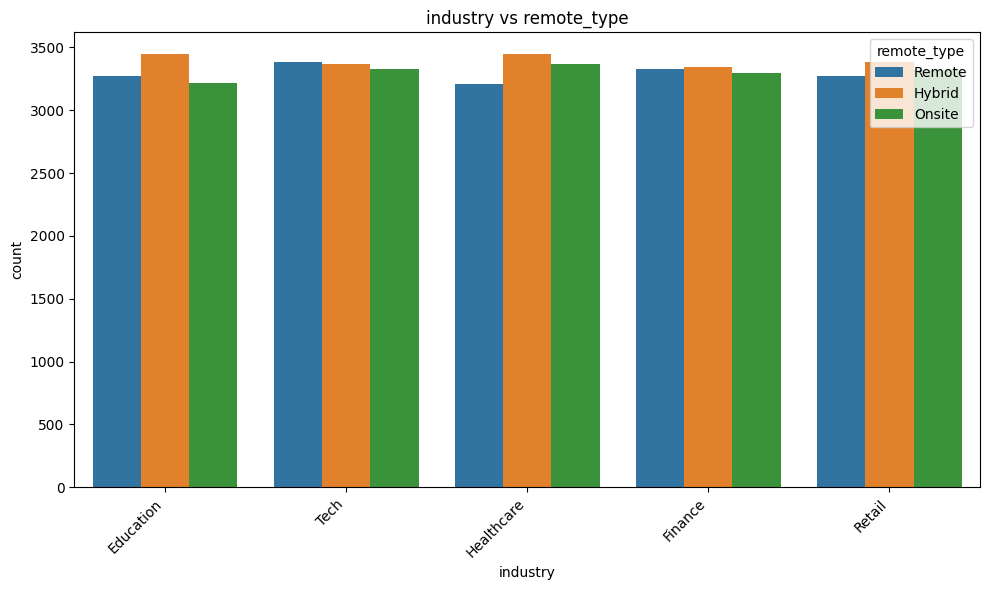

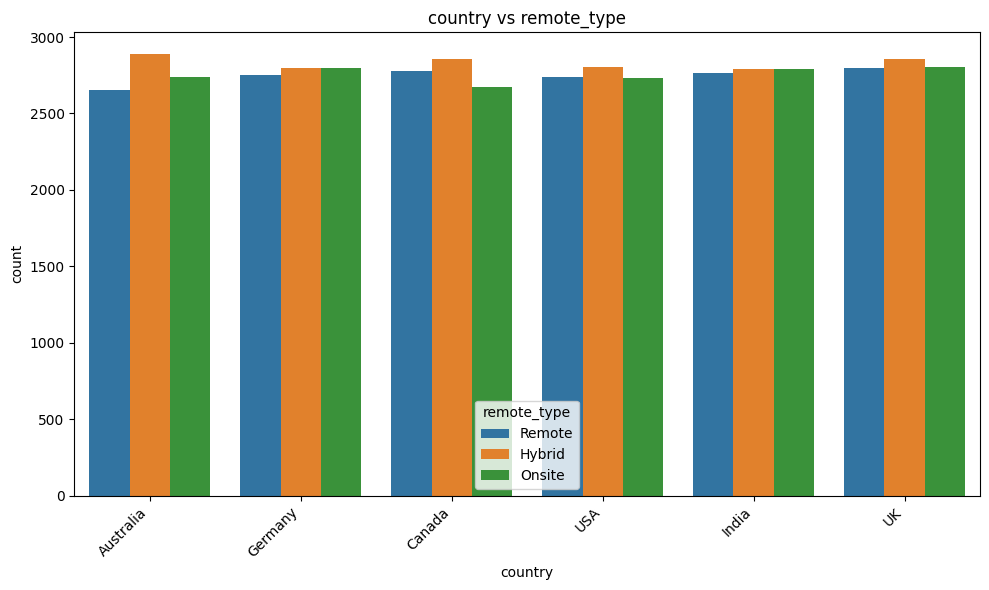

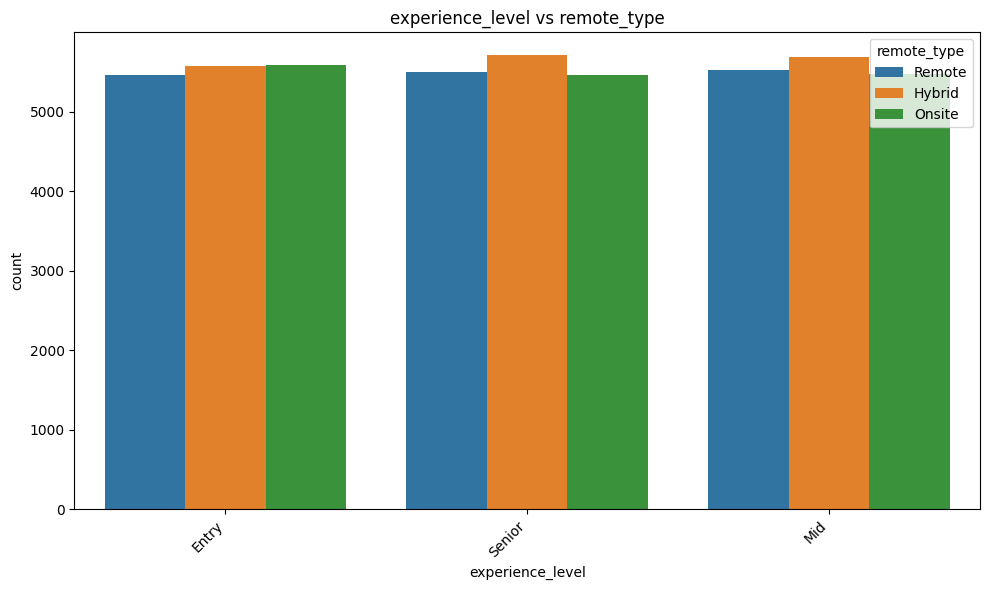

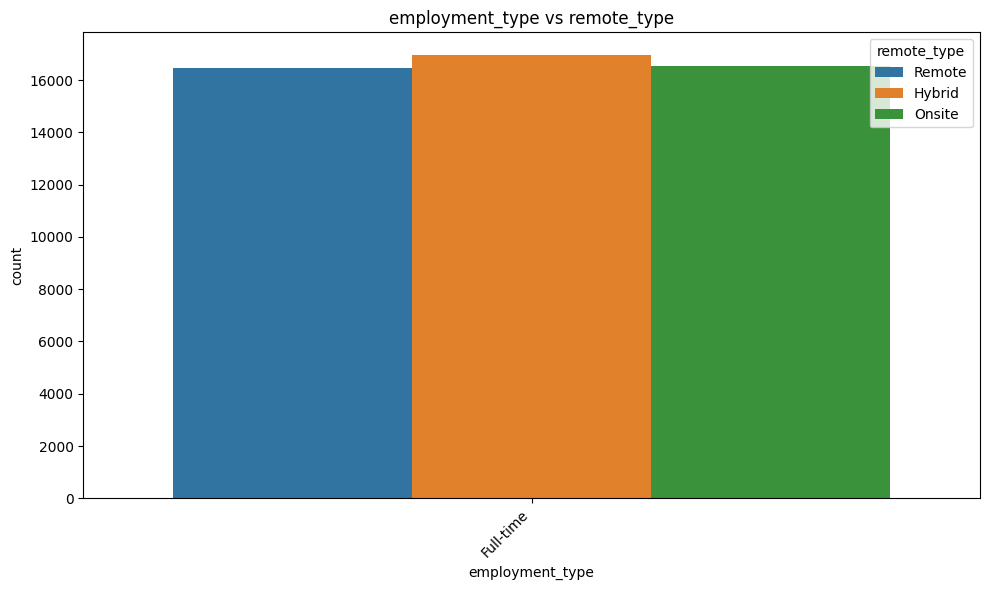

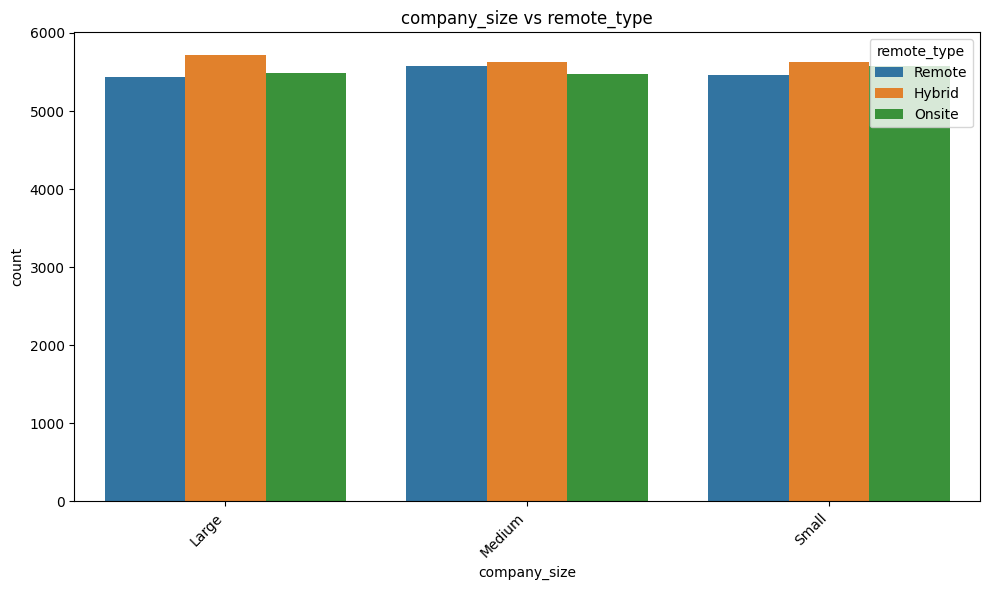

In [31]:
#for bar graphs
df = df.drop(columns=['city'])
categorical_cols = ['job_title', 'company_type', 'industry', 'country', 'experience_level', 'employment_type', 'company_size']

#for box plots
numerical_cols = ['min_experience_years', 'salary_min_usd', 'salary_max_usd', 'posted_year']
target = 'remote_type'

for col in categorical_cols:
    plt.figure(figsize=(10,6))
    sns.countplot(data=df, x=col, hue=target)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{col} vs {target}')
    plt.tight_layout()
    plt.show()

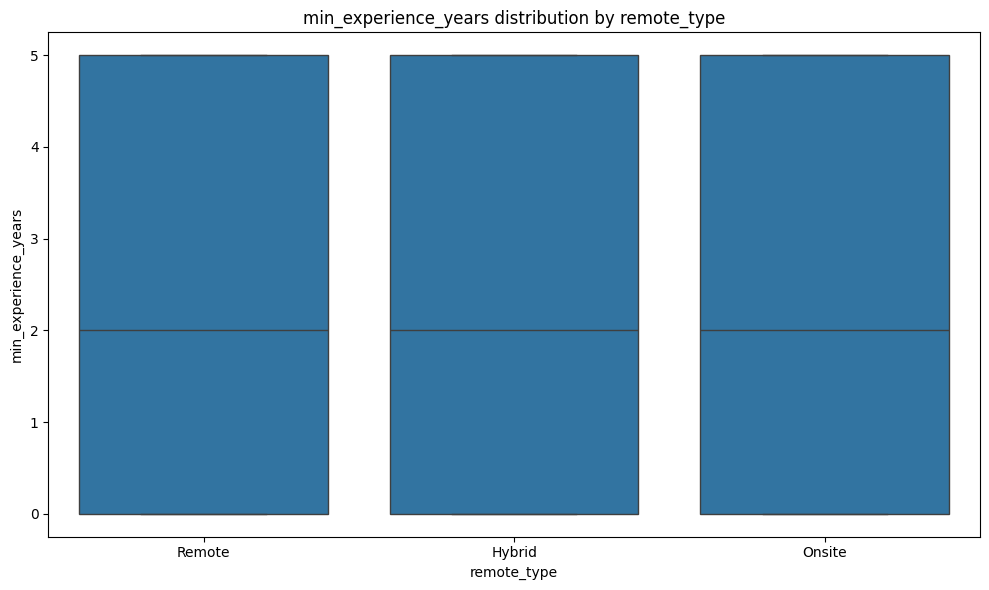

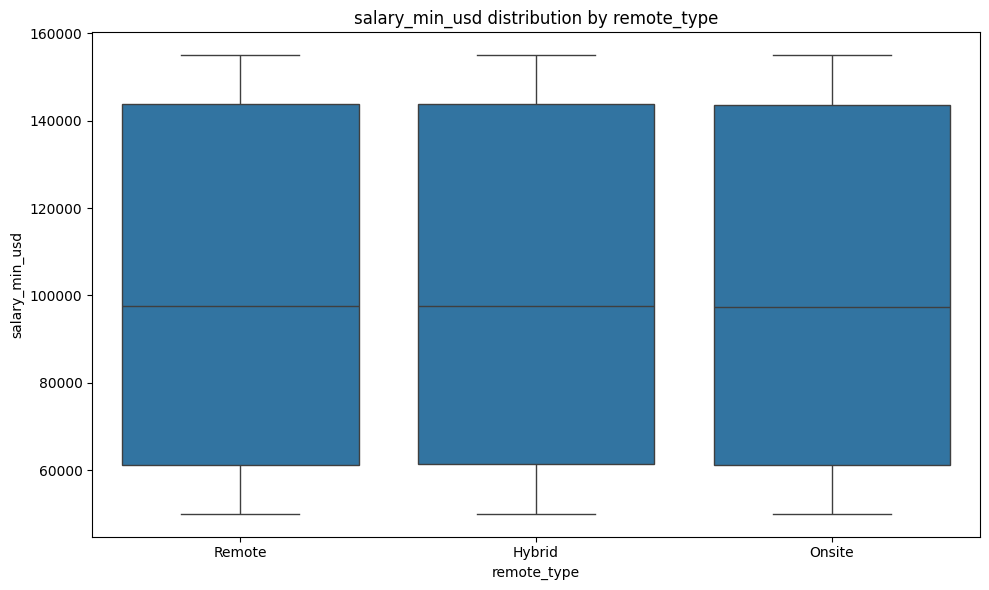

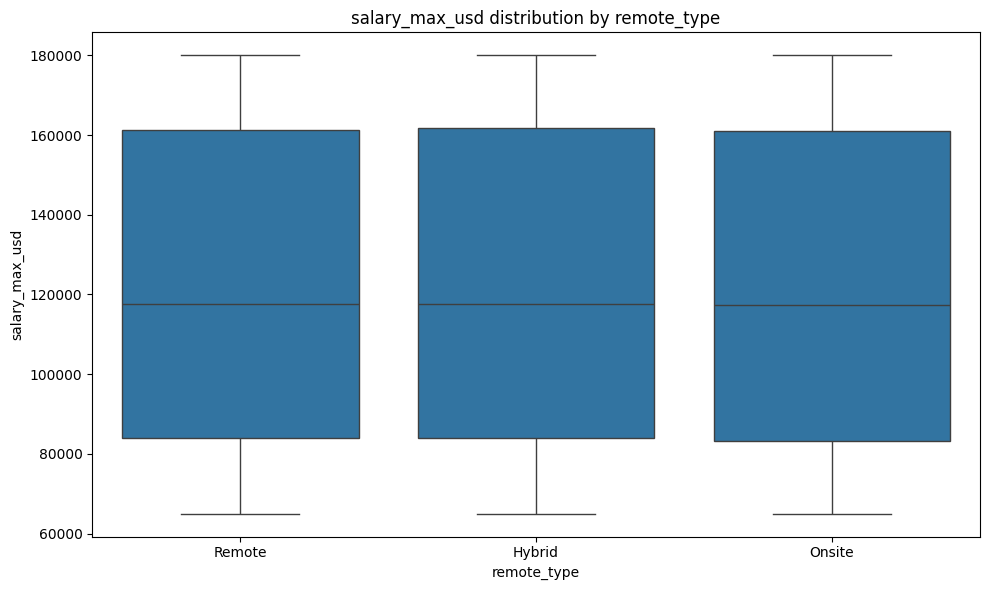

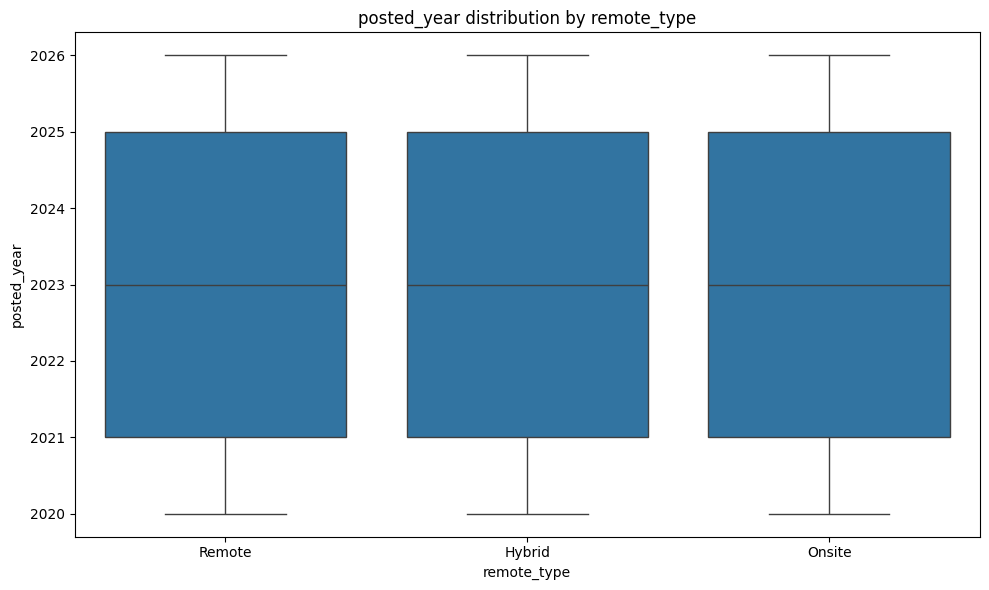

In [32]:
for col in numerical_cols:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f'{col} distribution by {target}')
    plt.tight_layout()
    plt.show()

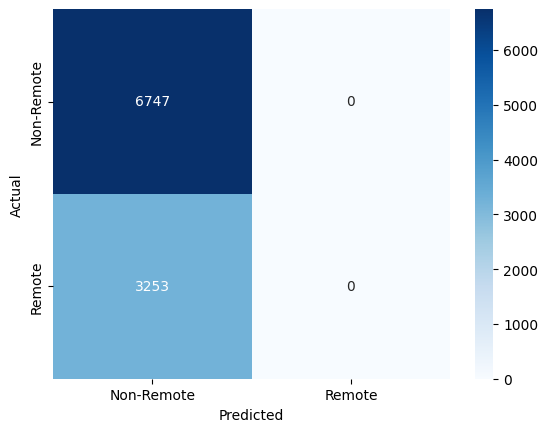

                                feature  coefficient
21              experience_level_Senior    -0.213709
0                  min_experience_years     0.212297
6              job_title_Data Scientist     0.118470
1                        salary_min_usd    -0.106306
15                       country_Canada     0.068477
19                          country_USA     0.051618
20                 experience_level_Mid    -0.051279
17                        country_India     0.050390
22                  company_size_Medium     0.049729
8   job_title_Machine Learning Engineer    -0.046677
16                      country_Germany     0.046094
5                job_title_Data Analyst     0.043709
7              job_title_MLOps Engineer     0.039732
14                        industry_Tech     0.037924
4           job_title_Applied Scientist     0.037825
18                           country_UK     0.027940
11                     industry_Finance     0.023459
9             company_type_Research Lab    -0.

-0.0008483515715100864

In [33]:
#treat remote as 1, hybrid and in person as zero (as both hybrid and in person would require you to live in the city the job is in)

df['remote_binary'] = df['remote_type'].apply(lambda x: 1 if x == 'Remote' else 0)
target = 'remote_binary'


#needed to be able to do any form of regression with the many categorical columns in our dataframe
X_cat = pd.get_dummies(df[categorical_cols], drop_first=True)

#scale numeric columns so they have zero mean and unit variance.
#this helps logistic regression treat all features equally and improves convergence.

scaler = StandardScaler()
X_num = pd.DataFrame(scaler.fit_transform(df[numerical_cols]), columns=numerical_cols)

#combine numeric and categorical features into a single DataFrame for modeling
X = pd.concat([X_num, X_cat], axis=1)
y = df[target]

#split dataset into training and test sets for model evaluation (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#initialize model and fit on the training set
model = LogisticRegression()
model.fit(X_train, y_train)

#get predictions
y_pred = model.predict(X_test)

#create a confusion matrix where correctly predicted entries are counted in the top left or bottom right
cm = confusion_matrix(y_test, y_pred)

#use seaborn to display our confusion matrix. Turn on numbers, format as ints, label axis
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Remote','Remote'], yticklabels=['Non-Remote','Remote'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

feature_importance = pd.DataFrame({ 'feature': X.columns, 'coefficient': model.coef_[0] }).sort_values(by='coefficient', key=abs, ascending=False)

print(feature_importance.head(20))

ols = LinearRegression()
ols.fit(X_train, y_train)

# Predictions
y2_pred = ols.predict(X_test)
r2_test = ols.score(X_test, y_test)
r2_test

In [34]:
print(accuracy_score(y_test, y_pred))

0.6747


After removing location-based leakage, logistic regression achieved 67.47% accuracy, equal to the majority class baseline. This suggests that remote status is not meaningfully predicted by job title, salary, experience level, company type, or posting year in this dataset.

In [35]:
#features for what variables are most powerful in predicting salary
features = ['remote_type', 'experience_level','job_title']

#get dummies for all the categorical features
X = pd.get_dummies(df[features], drop_first=True)
y = df['salary_mid']

#split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42069)

#initialize the model
model = LinearRegression()
model.fit(X_train, y_train)

#evaluating fit
r2 = model.score(X_train, y_train)
print("R^2 Train:", round(r2,5))
r2_test = model.score(X_test, y_test)
print("R^2 Test:", round(r2_test,5))

R^2 Train: 0.98716
R^2 Test: 0.98718


$R^2$ was nearly idenitical here for the LeastSquares model train/test on predicting median salary with remote type, experience level, and job title.  

In [36]:
#looking at the slopes for the features
coefs = model.coef_
#creating a dataframe out of a dictionary of the features from x after we created dummies and their corresponding coefficients from the models.
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefs})
#corting the dataframe by highest to lowest coefficients
coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)
coef_df

,Feature,Coefficient
3,experience_level_Senior,89996.447865
2,experience_level_Mid,40010.834108
4,job_title_Applied Scientist,-95.320373
6,job_title_Data Scientist,81.777671
8,job_title_Machine Learning Engineer,-74.146918
1,remote_type_Remote,-37.353969
7,job_title_MLOps Engineer,-29.174281
5,job_title_Data Analyst,21.519028
0,remote_type_Onsite,-14.737224


In [37]:
#need to get the p-values, was getting an error about datatypes so cast directly to float
X_numeric = X.astype(float)
#add the constant as sm doesnt add the constant by default
X_numeric = sm.add_constant(X_numeric)
#create the model and fit it
ols_model = sm.OLS(y, X_numeric).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             salary_mid   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                 4.271e+05
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:42:00   Log-Likelihood:            -4.8806e+05
No. Observations:               50000   AIC:                         9.761e+05
Df Residuals:                   49990   BIC:                         9.762e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

p values ere only signigicant for experience level and applied scientist (negative slope, so evidence that this job is correlated with getting paid less)

In [38]:
#trying to now answer the research question Do startups pay differently vs MNCs (company type) after controlling for role + experience.
features = ['company_type', 'experience_level', 'job_title']

#dummy it up for the new features
X_comp = pd.get_dummies(df[features], drop_first=True)

#i dont want that error about dtypes again, but I am confused. shouldnt get_dummies always make floats?
X_comp = X_comp.astype(float)

#now have swapped off of sk learn because i want the p values in the end
X_comp = sm.add_constant(X_comp)

#fitting my OLS
ols_model_comp = sm.OLS(df['salary_mid'], X_comp).fit()

# Show summary with coefficients and p-values
print(ols_model_comp.summary())

                            OLS Regression Results                            
Dep. Variable:             salary_mid   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                 4.271e+05
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:42:33   Log-Likelihood:            -4.8806e+05
No. Observations:               50000   AIC:                         9.761e+05
Df Residuals:                   49990   BIC:                         9.762e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

company type of a research lab had statistifcally significant results, but startups did not. Research labs, we have evidence to say pay 93 dollars more (woohoo) than MSCs

mid level employees and senior have significant effects over junior employees, and the difference is 40k for mid and 90k more for senior.

data too cherry picked to have any value on job type.